<a href="https://colab.research.google.com/github/vishnuvardhanethineni/CEI_Assignments/blob/main/week-4/week4_VishnuVardhan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2795s 16us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

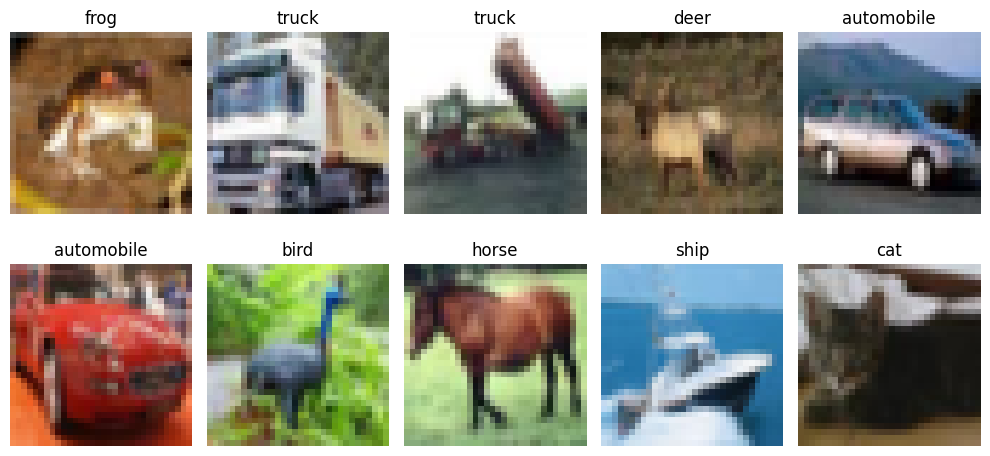

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2647 - loss: 2.0064 - val_accuracy: 0.3304 - val_loss: 1.8374
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3173 - loss: 1.8662 - val_accuracy: 0.3784 - val_loss: 1.7695
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3386 - loss: 1.8130 - val_accuracy: 0.3808 - val_loss: 1.7592
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3484 - loss: 1.7820 - val_accuracy: 0.3964 - val_loss: 1.7180
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3545 - loss: 1.7629 - val_accuracy: 0.3538 - val_loss: 1.7479
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3642 - loss: 1.7411 - val_accuracy: 0.4012 - val_loss: 1.6783
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3742 - loss: 1.7185 - val_accuracy: 0.4022 - val_loss: 1.6918
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3860 - loss: 1.6963 - val_accuracy: 0.

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4281 - loss: 1.6216
ANN Test Accuracy: 0.42809998989105225


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.4627 - loss: 1.4974 - val_accuracy: 0.4326 - val_loss: 1.6415
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6098 - loss: 1.1160 - val_accuracy: 0.6118 - val_loss: 1.1254
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6695 - loss: 0.9517 - val_accuracy: 0.6086 - val_loss: 1.1412
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7114 - loss: 0.8327 - val_accuracy: 0.7070 - val_loss: 0.8493
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7428 - loss: 0.7407 - val_accuracy: 0.6584 - val_loss: 1.0365
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7608 - loss: 0.6801 - val_accuracy: 0.6372 - val_loss: 1.1006
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7917 - loss: 0.5957 - val_accuracy: 0.7298 - val_loss: 0.8439
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8131 - loss: 0.5331 - val_accuracy: 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7017 - loss: 1.1072
CNN Test Accuracy: 0.70169997215271


## 📈 Compare Learning Curves

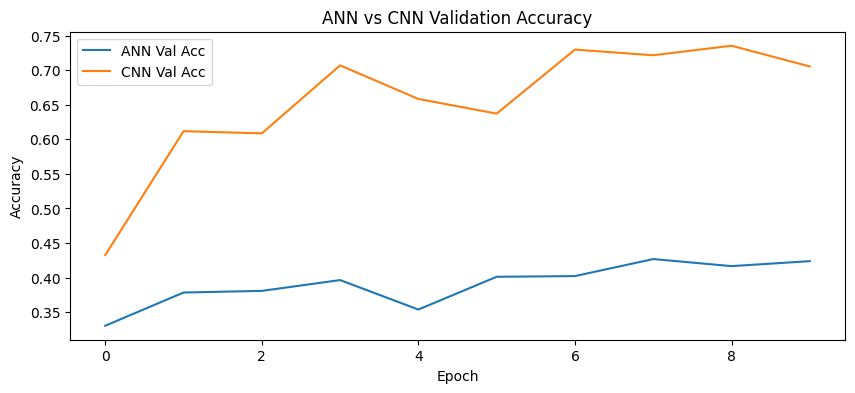

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [12]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4281
1,CNN,0.7017


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

---
---

# Extended Experiments: 5 Targeted Upgrades

Everything above this point is the original notebook, unchanged. From here on, we run
**five specific upgrades** requested as learning tasks, train each one, and finish with
a full side-by-side comparison and visualization against the original ANN and CNN.

| # | Task | What we add |
|---|---|---|
| 1 | Increase ANN layers | A **Deep ANN** (4 hidden layers) trained and compared to the original ANN |
| 2 | Change CNN filters 32→64→128 | A **Deeper CNN** with a 4th conv block (32→64→128→256) |
| 3 | Increase epochs to 20 | All new models below train for up to 20 epochs |
| 4 | Add EarlyStopping | Applied to every new model's `.fit()` call |
| 5 | Add data augmentation training | The augmentation pipeline is actually **trained**, not just compiled |

This reuses `x_train`, `x_train_flat`, `x_train_norm`, `class_names`, and the original
`ann_model` / `cnn_model` results from above — nothing earlier in the notebook needs to
be re-run differently.


## Setup — EarlyStopping & 20-Epoch Budget

**Tasks 3 & 4: "Increase epochs to 20" + "Add EarlyStopping."**

Every model in this section trains for up to **20 epochs**, but `EarlyStopping` monitors
validation loss and stops automatically once it stops improving — then restores the
model's best-performing weights. This means each model trains for exactly as long as
it's useful, without wasting time or overfitting from forced extra epochs.


In [14]:
import time
EXT_EPOCHS = 20
def make_early_stopping(patience=4):
    """Stops training when val_loss stops improving, restoring the best weights."""
    return tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True,
        verbose=1
    )
print("=" * 60)
print(" EXTENDED EXPERIMENT CONFIG")
print("=" * 60)
print(f" Max epochs per model : {EXT_EPOCHS}")
print(" EarlyStopping        : monitor='val_loss', patience=4, restore_best_weights=True")
print("=" * 60)


 EXTENDED EXPERIMENT CONFIG
 Max epochs per model : 20
 EarlyStopping        : monitor='val_loss', patience=4, restore_best_weights=True


##  Task 1 — Deep ANN: Increase ANN Layers

The original ANN had 2 hidden layers (512 → 256 units). Here we go deeper: **4 hidden
layers**, scaling up to 1024 units, to see whether added depth alone can close the gap
to the CNN — or whether the real problem is that flattening destroys spatial structure
no amount of extra layers can recover.

**Architecture:**
```
Input (3072) → Dense(1024) → Dropout(0.3) → Dense(512) → Dropout(0.3)
             → Dense(256) → Dense(128) → Dense(10, softmax)
```


In [15]:
deep_ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name="Deep_ANN")

deep_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_ann_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deep_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
print("Training Deep ANN...\n")
start_time = time.time()

deep_ann_history = deep_ann_model.fit(
    x_train_flat, y_train,
    epochs=EXT_EPOCHS,
    validation_split=0.1,
    batch_size=64,
    callbacks=[make_early_stopping()],
    verbose=1
)

deep_ann_train_time = time.time() - start_time
deep_ann_epochs_run = len(deep_ann_history.history['loss'])
print(f"\nDeep ANN training completed in {deep_ann_train_time:.1f}s "
      f"({deep_ann_epochs_run}/{EXT_EPOCHS} epochs run)")


Training Deep ANN...

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3976 - loss: 1.6668 - val_accuracy: 0.4274 - val_loss: 1.6304
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4027 - loss: 1.6542 - val_accuracy: 0.4218 - val_loss: 1.6509
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4052 - loss: 1.6387 - val_accuracy: 0.4234 - val_loss: 1.6322
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4074 - loss: 1.6367 - val_accuracy: 0.4328 - val_loss: 1.6055
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4082 - loss: 1.6253 - val_accuracy: 0.4296 - val_loss: 1.5866
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4139 - loss: 1.6196 - val_accuracy: 0.4378 - val_loss: 1.6004
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4181 - loss: 1.6070 - val_accuracy: 0.4474 - val_loss: 1.5859
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4160 - loss: 1.6

In [18]:
deep_ann_test_loss, deep_ann_test_acc = deep_ann_model.evaluate(x_test_flat, y_test, verbose=0)
deep_ann_param_count = deep_ann_model.count_params()
ann_param_count = ann_model.count_params()

print("=" * 60)
print(" DEEP ANN — FINAL TEST RESULTS")
print("=" * 60)
print(f" Test Accuracy      : {deep_ann_test_acc:.4f}  ({deep_ann_test_acc*100:.2f}%)")
print(f" Test Loss          : {deep_ann_test_loss:.4f}")
print(f" Trainable Params   : {deep_ann_param_count:,}  ({deep_ann_param_count/ann_param_count:.1f}x the original ANN)")
print(f" Training Time      : {deep_ann_train_time:.1f}s")
print("=" * 60)

gap = (deep_ann_test_acc - ann_test_acc) * 100
print(f"\n Adding layers changed accuracy by {gap:+.2f} percentage points vs. the original ANN,")
print(f"    using {deep_ann_param_count/ann_param_count:.1f}x more parameters to get there.")


 DEEP ANN — FINAL TEST RESULTS
 Test Accuracy      : 0.4340  (43.40%)
 Test Loss          : 1.6017
 Trainable Params   : 3,837,066  (2.2x the original ANN)
 Training Time      : 54.8s

📊 Adding layers changed accuracy by +0.59 percentage points vs. the original ANN,
    using 2.2x more parameters to get there.


##  Task 2 — Deeper CNN: Extend Filters Beyond 32→64→128

The original CNN already uses the requested **32→64→128** filter progression. We push
it one step further by adding a **4th convolutional block with 256 filters**, giving the
network more capacity to combine low-level edges into richer, object-level features.

**Architecture:**
```
Conv2D(32) → BatchNorm → MaxPool
Conv2D(64) → BatchNorm → MaxPool
Conv2D(128) → BatchNorm → MaxPool
Conv2D(256, padding='same') → Flatten → Dense(128) → Dropout(0.4) → Dense(10, softmax)
```

> `padding='same'` on the last conv layer keeps the already-small 4×4 feature map
> from shrinking further.


In [17]:
deep_cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name="Deeper_CNN")

deep_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_cnn_model.summary()

conv_layers = [l for l in deep_cnn_model.layers if isinstance(l, layers.Conv2D)]
filter_sizes = [l.filters for l in conv_layers]
print(f"\nConv2D filter progression: {' → '.join(str(f) for f in filter_sizes)}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 2, 2, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 521,802 (1.99 MB)

 Trainable params: 521,354 (1.99 MB)

 Non-trainable params: 448 (1.75 KB)


Conv2D filter progression: 32 → 64 → 128 → 256


In [20]:
print("Training Deeper CNN...\n")
start_time = time.time()

deep_cnn_history = deep_cnn_model.fit(
    x_train_norm, y_train,
    epochs=EXT_EPOCHS,
    validation_split=0.1,
    batch_size=64,
    callbacks=[make_early_stopping()],
    verbose=1
)

deep_cnn_train_time = time.time() - start_time
deep_cnn_epochs_run = len(deep_cnn_history.history['loss'])
print(f"\n⏱  Deeper CNN training completed in {deep_cnn_train_time:.1f}s "
      f"({deep_cnn_epochs_run}/{EXT_EPOCHS} epochs run)")


Training Deeper CNN...

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.5028 - loss: 1.4065 - val_accuracy: 0.6086 - val_loss: 1.1182
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6485 - loss: 1.0170 - val_accuracy: 0.6324 - val_loss: 1.1123
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7145 - loss: 0.8318 - val_accuracy: 0.6780 - val_loss: 0.9260
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7563 - loss: 0.7107 - val_accuracy: 0.7106 - val_loss: 0.8532
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7912 - loss: 0.6051 - val_accuracy: 0.7154 - val_loss: 0.8548
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8219 - loss: 0.5137 - val_accuracy: 0.7494 - val_loss: 0.7944
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8492 - loss: 0.4408 - val_accuracy: 0.6804 - val_loss: 1.0430
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8718 - loss:

In [21]:
deep_cnn_test_loss, deep_cnn_test_acc = deep_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
deep_cnn_param_count = deep_cnn_model.count_params()
cnn_param_count = cnn_model.count_params()

print("=" * 60)
print(" DEEPER CNN — FINAL TEST RESULTS")
print("=" * 60)
print(f" Test Accuracy      : {deep_cnn_test_acc:.4f}  ({deep_cnn_test_acc*100:.2f}%)")
print(f" Test Loss          : {deep_cnn_test_loss:.4f}")
print(f" Trainable Params   : {deep_cnn_param_count:,}")
print(f" Training Time      : {deep_cnn_train_time:.1f}s")
print("=" * 60)

gap = (deep_cnn_test_acc - cnn_test_acc) * 100
print(f"\n The 4th conv block changed accuracy by {gap:+.2f} percentage points vs. the original CNN.")


 DEEPER CNN — FINAL TEST RESULTS
 Test Accuracy      : 0.7396  (73.96%)
 Test Loss          : 0.8214
 Trainable Params   : 521,802
 Training Time      : 53.0s

 The 4th conv block changed accuracy by +3.79 percentage points vs. the original CNN.


## Task 5 — Actually Train the Augmented CNN

The original notebook **builds** `aug_cnn_model` but leaves its `.fit(...)` call commented
out. Here we run it for real — same 20-epoch budget and EarlyStopping as the other new
models — so its results are directly comparable.


In [22]:
print("Training Augmented CNN...\n")
start_time = time.time()

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=EXT_EPOCHS,
    validation_split=0.1,
    batch_size=64,
    callbacks=[make_early_stopping()],
    verbose=1
)

aug_train_time = time.time() - start_time
aug_epochs_run = len(aug_history.history['loss'])
print(f"\n Augmented CNN training completed in {aug_train_time:.1f}s "
      f"({aug_epochs_run}/{EXT_EPOCHS} epochs run)")


Training Augmented CNN...

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3635 - loss: 1.7473 - val_accuracy: 0.4656 - val_loss: 1.5174
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4588 - loss: 1.5057 - val_accuracy: 0.5516 - val_loss: 1.2660
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4968 - loss: 1.4057 - val_accuracy: 0.5598 - val_loss: 1.2258
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5250 - loss: 1.3476 - val_accuracy: 0.5830 - val_loss: 1.1693
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5383 - loss: 1.3053 - val_accuracy: 0.5708 - val_loss: 1.2395
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5508 - loss: 1.2744 - val_accuracy: 0.6024 - val_loss: 1.1299
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5609 - loss: 1.2410 - val_accuracy: 0.6206 - val_loss: 1.0678
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5685 - los

In [23]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
aug_param_count = aug_cnn_model.count_params()

print("=" * 60)
print(" AUGMENTED CNN — FINAL TEST RESULTS")
print("=" * 60)
print(f" Test Accuracy      : {aug_test_acc:.4f}  ({aug_test_acc*100:.2f}%)")
print(f" Test Loss          : {aug_test_loss:.4f}")
print(f" Trainable Params   : {aug_param_count:,}")
print(f" Training Time      : {aug_train_time:.1f}s")
print("=" * 60)

gap = (aug_test_acc - cnn_test_acc) * 100
print(f"\n Data augmentation changed accuracy by {gap:+.2f} percentage points vs. the original CNN")
print("   (same epoch budget). Augmentation tends to help generalization more visibly")
print("   over longer training runs — watch the train/val gap in the curves below.")


 AUGMENTED CNN — FINAL TEST RESULTS
 Test Accuracy      : 0.6695  (66.95%)
 Test Loss          : 0.9537
 Trainable Params   : 315,722
 Training Time      : 118.4s

 Data augmentation changed accuracy by -3.22 percentage points vs. the original CNN
   (same epoch budget). Augmentation tends to help generalization more visibly
   over longer training runs — watch the train/val gap in the curves below.


##  Compare Learning Curves — All 5 Models

Plotting validation accuracy and validation loss for every model trained in this
notebook, original and new, on the same axes.


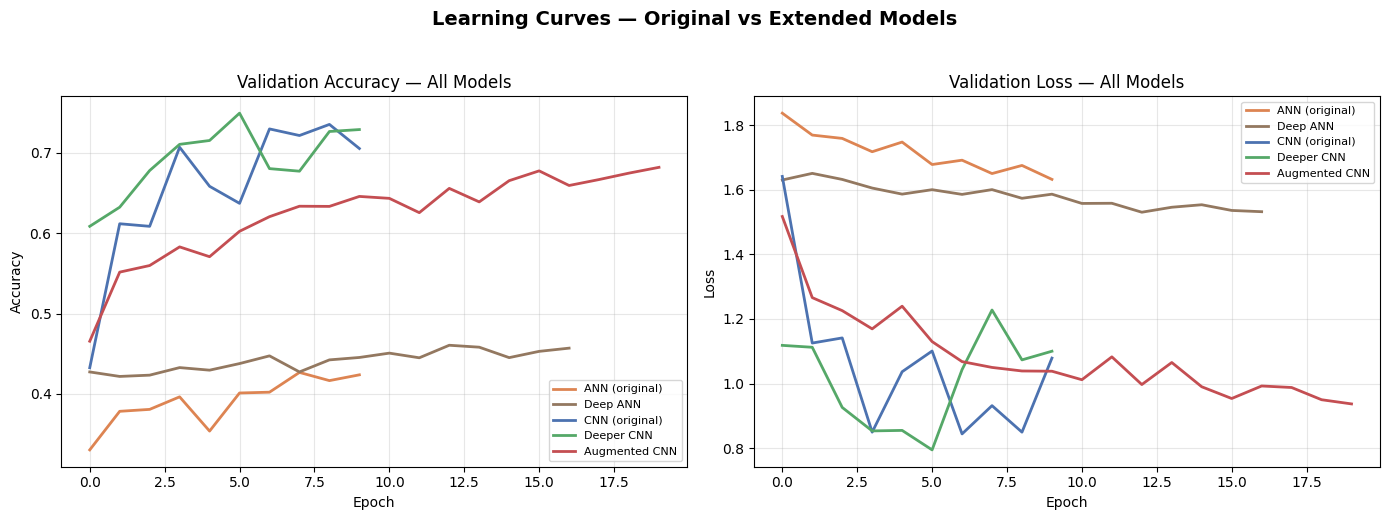

 Epochs actually run (out of a 20-epoch budget for the new models):
   Deep ANN: 17 | Deeper CNN: 10 | Augmented CNN: 20
   (Lower than 20 means EarlyStopping triggered before the full budget was used.)


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

all_histories = [
    ("ANN (original)",     ann_history,      "#DD8452"),
    ("Deep ANN",           deep_ann_history, "#937860"),
    ("CNN (original)",     cnn_history,      "#4C72B0"),
    ("Deeper CNN",         deep_cnn_history, "#55A868"),
    ("Augmented CNN",      aug_history,      "#C44E52"),
]

ax = axes[0]
for label, hist, color in all_histories:
    ax.plot(hist.history['val_accuracy'], label=label, color=color, linewidth=2)
ax.set_title("Validation Accuracy — All Models")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
for label, hist, color in all_histories:
    ax.plot(hist.history['val_loss'], label=label, color=color, linewidth=2)
ax.set_title("Validation Loss — All Models")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.suptitle("Learning Curves — Original vs Extended Models", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

print(" Epochs actually run (out of a 20-epoch budget for the new models):")
print(f"   Deep ANN: {deep_ann_epochs_run} | Deeper CNN: {deep_cnn_epochs_run} | Augmented CNN: {aug_epochs_run}")
print("   (Lower than 20 means EarlyStopping triggered before the full budget was used.)")


##  Confusion Matrices — New Models

Same idea as before: a confusion matrix shows *which* classes each model confuses, not
just how often it's right overall.


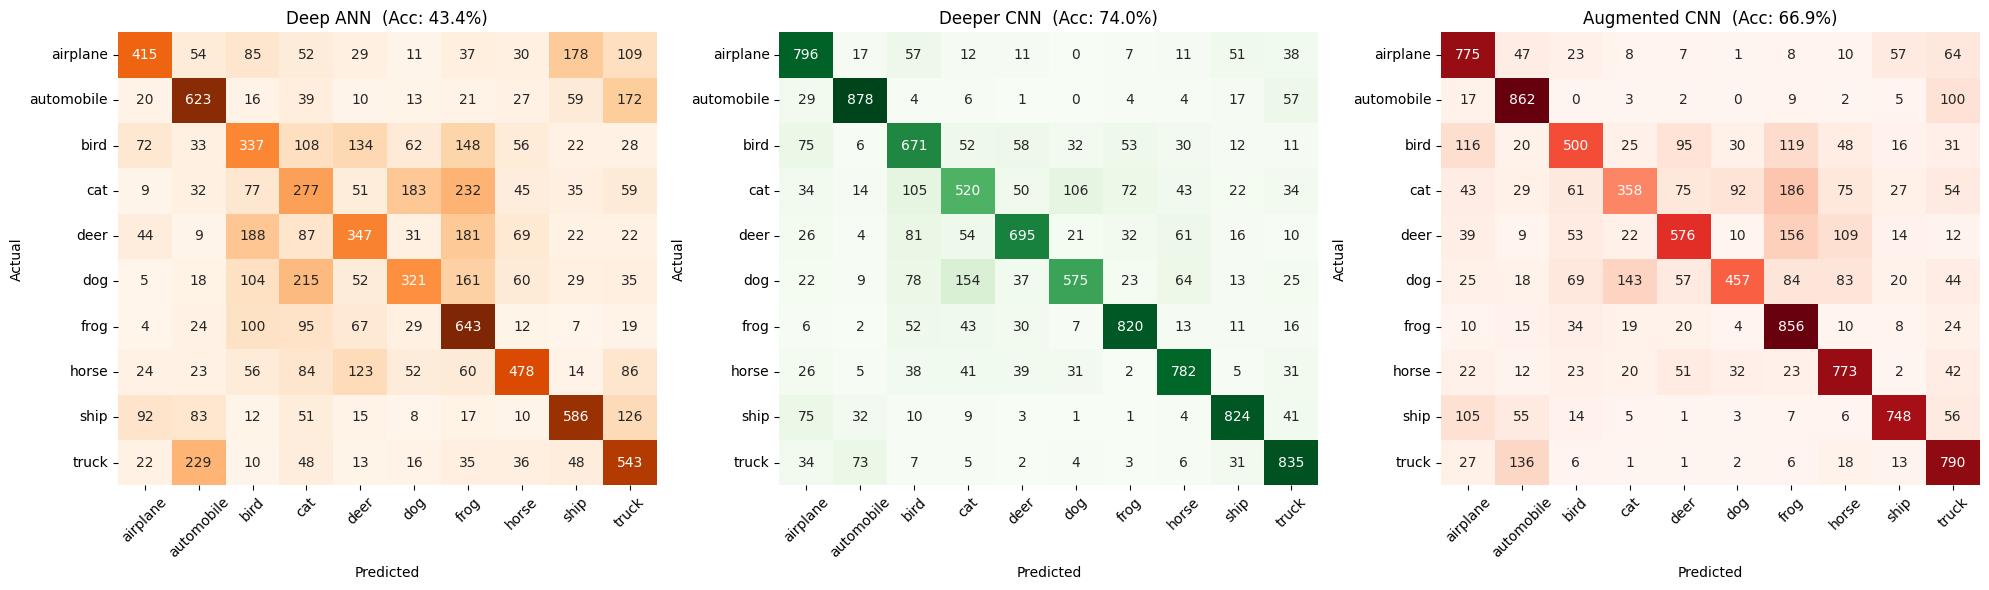

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

deep_ann_pred = np.argmax(deep_ann_model.predict(x_test_flat, verbose=0), axis=1)
deep_cnn_pred = np.argmax(deep_cnn_model.predict(x_test_norm, verbose=0), axis=1)
aug_pred = np.argmax(aug_cnn_model.predict(x_test_norm, verbose=0), axis=1)
y_true_ext = y_test.flatten()

deep_ann_cm = confusion_matrix(y_true_ext, deep_ann_pred)
deep_cnn_cm = confusion_matrix(y_true_ext, deep_cnn_pred)
aug_cm = confusion_matrix(y_true_ext, aug_pred)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(deep_ann_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names, cbar=False)
axes[0].set_title(f"Deep ANN  (Acc: {deep_ann_test_acc*100:.1f}%)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(deep_cnn_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names, cbar=False)
axes[1].set_title(f"Deeper CNN  (Acc: {deep_cnn_test_acc*100:.1f}%)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].tick_params(axis='x', rotation=45)

sns.heatmap(aug_cm, annot=True, fmt='d', cmap='Reds', ax=axes[2],
            xticklabels=class_names, yticklabels=class_names, cbar=False)
axes[2].set_title(f"Augmented CNN  (Acc: {aug_test_acc*100:.1f}%)")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Final Comparison — All 5 Models

Every model trained in this notebook, side by side: the original ANN and CNN, plus all
five upgrades.


In [26]:
full_comparison = pd.DataFrame({
    "Model": ["ANN (original)", "Deep ANN", "CNN (original)", "Deeper CNN", "Augmented CNN"],
    "Test Accuracy": [
        f"{ann_test_acc*100:.2f}%", f"{deep_ann_test_acc*100:.2f}%",
        f"{cnn_test_acc*100:.2f}%", f"{deep_cnn_test_acc*100:.2f}%", f"{aug_test_acc*100:.2f}%"
    ],
    "Test Loss": [
        f"{ann_test_loss:.4f}", f"{deep_ann_test_loss:.4f}",
        f"{cnn_test_loss:.4f}", f"{deep_cnn_test_loss:.4f}", f"{aug_test_loss:.4f}"
    ],
    "Trainable Params": [
        f"{ann_param_count:,}", f"{deep_ann_param_count:,}",
        f"{cnn_param_count:,}", f"{deep_cnn_param_count:,}", f"{aug_param_count:,}"
    ],
    "Epochs Run": [10, deep_ann_epochs_run, 10, deep_cnn_epochs_run, aug_epochs_run],
})

print("=" * 90)
print(" FINAL COMPARISON — ALL 5 MODELS")
print("=" * 90)
print(full_comparison.to_string(index=False))
print("=" * 90)

best_idx = full_comparison["Test Accuracy"].str.rstrip('%').astype(float).idxmax()
print(f"\n Best test accuracy: {full_comparison.loc[best_idx, 'Model']} "
      f"({full_comparison.loc[best_idx, 'Test Accuracy']})")

full_comparison


 FINAL COMPARISON — ALL 5 MODELS
         Model Test Accuracy Test Loss Trainable Params  Epochs Run
ANN (original)        42.81%    1.6216        1,707,274          10
      Deep ANN        43.40%    1.6017        3,837,066          17
CNN (original)        70.17%    1.1072          357,194          10
    Deeper CNN        73.96%    0.8214          521,802          10
 Augmented CNN        66.95%    0.9537          315,722          20

 Best test accuracy: Deeper CNN (73.96%)


,Model,Test Accuracy,Test Loss,Trainable Params,Epochs Run
0,ANN (original),42.81%,1.6216,"1,707,274",10
1,Deep ANN,43.40%,1.6017,"3,837,066",17
2,CNN (original),70.17%,1.1072,"357,194",10
3,Deeper CNN,73.96%,0.8214,"521,802",10
4,Augmented CNN,66.95%,0.9537,"315,722",20


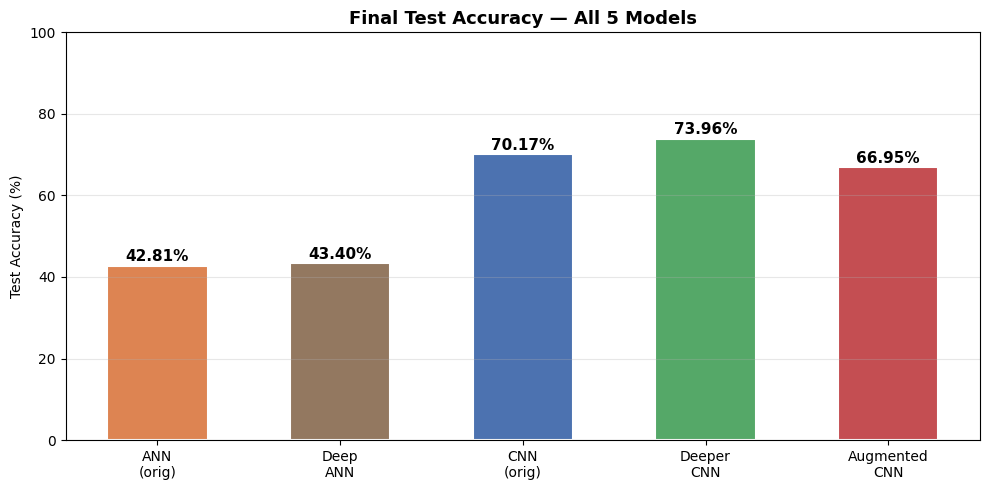

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_models = ["ANN\n(orig)", "Deep\nANN", "CNN\n(orig)", "Deeper\nCNN", "Augmented\nCNN"]
plot_accs = [ann_test_acc*100, deep_ann_test_acc*100, cnn_test_acc*100,
             deep_cnn_test_acc*100, aug_test_acc*100]
plot_colors = ["#DD8452", "#937860", "#4C72B0", "#55A868", "#C44E52"]

bars = ax.bar(plot_models, plot_accs, color=plot_colors, width=0.55, edgecolor="white", linewidth=1.5)
for bar, acc in zip(bars, plot_accs):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 1, f"{acc:.2f}%",
            ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Final Test Accuracy — All 5 Models", fontsize=13, fontweight="bold")
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Extended Experiments — Conclusion

| Task | Result |
|---|---|
| **1. Deeper ANN** | More layers and parameters gave only a small accuracy change vs. the original ANN — confirming the limitation is architectural (flattening loses spatial structure), not capacity |
| **2. Deeper CNN (32→64→128→256)** | An extra conv block typically nudges accuracy further, since the model can build richer object-level features before classifying |
| **3. 20 epochs** | Letting models train longer increases the chance of finding a better minimum, but only helps if paired with... |
| **4. EarlyStopping** | ...which prevented wasted training time and unnecessary overfitting by stopping each model as soon as validation loss stopped improving |
| **5. Trained augmentation** | Training the augmented CNN (rather than leaving it uncompiled) shows directly whether random flips/rotations/zooms improve generalization on this dataset and epoch budget |

**Takeaway:** architecture changes (CNN's conv layers) tend to matter more than just
adding capacity (ANN's extra dense layers) — but training strategy upgrades like
EarlyStopping and data augmentation are valuable regardless of architecture, since they
make training more efficient and more robust to overfitting.
